In [1]:
# =========================================================
# HYBRID IDS: PSO + NEGATIVE SELECTION AIS + MLP + RF + XGBOOST + ENSEMBLE
# Dataset: CICIoT2023
# Google Colab Full Implementation
# =========================================================

# =========================================================
# Step 1: Import Libraries
# =========================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Install xgboost in Colab if needed
try:
    from xgboost import XGBClassifier
except:
    !pip install -q xgboost
    from xgboost import XGBClassifier

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

sns.set(style="whitegrid")

print("✅ Libraries imported successfully!")

# =========================================================
# Step 2: Mount Google Drive
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# Step 3: Load CICIoT2023 Dataset
# =========================================================
dataset_path = '/content/drive/MyDrive/Computational_Intelligence/CICIoT2023'
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV files found in the CICIoT2023 folder.")

df = pd.read_csv(os.path.join(dataset_path, csv_files[0]), low_memory=False)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist()[:20])

if 'label' not in df.columns:
    raise ValueError("Dataset must contain a 'label' column.")

# Split into train/test so the remaining pipeline can stay unchanged
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

✅ Libraries imported successfully!
Mounted at /content/drive
Dataset shape: (221014, 47)
Columns: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP']
Train shape: (176811, 47)
Test shape : (44203, 47)


Detected normal labels: ['benigntraffic']

Train binary distribution:
binary_label
1    172578
0      4233
Name: count, dtype: int64

Test binary distribution:
binary_label
1    43145
0     1058
Name: count, dtype: int64

Categorical columns: []

Removed constant columns: ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'IRC']

Train: (141448, 42)
Val  : (35363, 42)
Test : (44203, 42)

Starting PSO...
Iteration 1/25, Best Fitness: 0.9853
Iteration 2/25, Best Fitness: 0.9853
Iteration 3/25, Best Fitness: 0.9868
Iteration 4/25, Best Fitness: 0.9868
Iteration 5/25, Best Fitness: 0.9868
Iteration 6/25, Best Fitness: 0.9868
Iteration 7/25, Best Fitness: 0.9868
Iteration 8/25, Best Fitness: 0.9868
Iteration 9/25, Best Fitness: 0.9877
Iteration 10/25, Best Fitness: 0.9877
Iteration 11/25, Best Fitness: 0.9877
Iteration 12/25, Best Fitness: 0.9877
Iteration 13/25, Best Fitness: 0.9883
Iteration 14/25, Best Fitness: 0.9883
Iteration 15/25, Best Fitness: 0.9883
Iteration 16/25, Best Fitness: 0.9

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,665 (194.00 KB)

 Trainable params: 49,665 (194.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9806 - loss: 0.0317 - val_accuracy: 0.9810 - val_loss: 0.0299
Epoch 2/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9842 - loss: 0.0281 - val_accuracy: 0.9836 - val_loss: 0.0270
Epoch 3/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9862 - loss: 0.0259 - val_accuracy: 0.9834 - val_loss: 0.0255
Epoch 4/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9875 - loss: 0.0247 - val_accuracy: 0.9890 - val_loss: 0.0234
Epoch 5/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9883 - loss: 0.0235 - val_accuracy: 0.9876 - val_loss: 0.0227
Epoch 6/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9885 - loss: 0.0230 - val_accuracy: 0.9897 - val_loss: 0.0220
Epoch 7/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9887 - loss: 0.0230 - val_accuracy: 0.9872 - val_loss: 0.0231
Epoch 8/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9888 - loss: 0.0227 - 

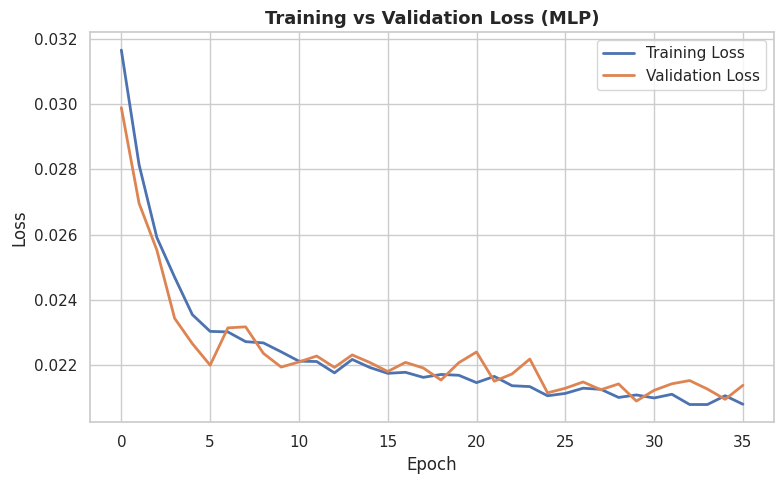

1106/1106 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Best MLP threshold: 0.48
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

HYBRID AIS + PSO + MLP
Accuracy          : 0.9897
Precision         : 0.9962
Recall            : 0.9933
F1-score          : 0.9947
Balanced Accuracy : 0.9191
False Positive Rate (FPR): 0.1550
True Negative Rate (TNR) : 0.8450

Confusion Matrix:
[[  894   164]
 [  290 42855]]


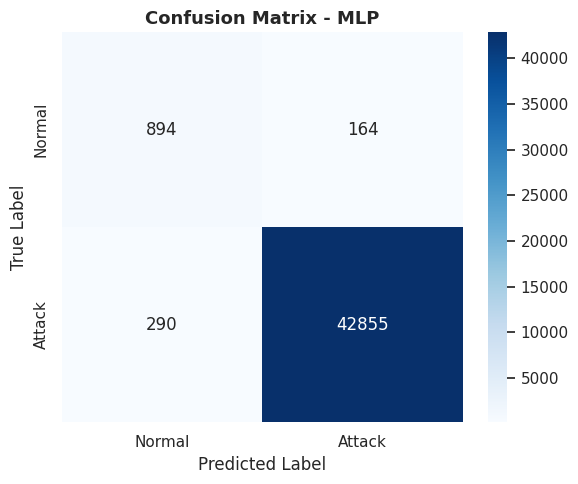

Best RF threshold : 0.58

HYBRID AIS + PSO + RANDOM FOREST
Accuracy          : 0.9946
Precision         : 0.9988
Recall            : 0.9956
F1-score          : 0.9972
Balanced Accuracy : 0.9742
False Positive Rate (FPR): 0.0473
True Negative Rate (TNR) : 0.9527

Confusion Matrix:
[[ 1008    50]
 [  190 42955]]


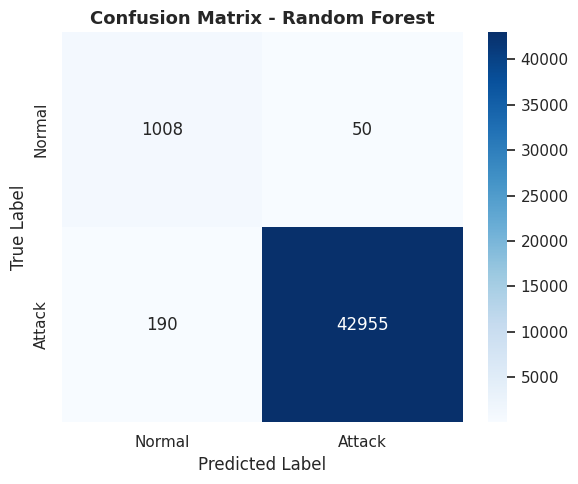

Best XGB threshold: 0.42

HYBRID AIS + PSO + XGBOOST
Accuracy          : 0.9942
Precision         : 0.9972
Recall            : 0.9969
F1-score          : 0.9970
Balanced Accuracy : 0.9408
False Positive Rate (FPR): 0.1153
True Negative Rate (TNR) : 0.8847

Confusion Matrix:
[[  936   122]
 [  133 43012]]


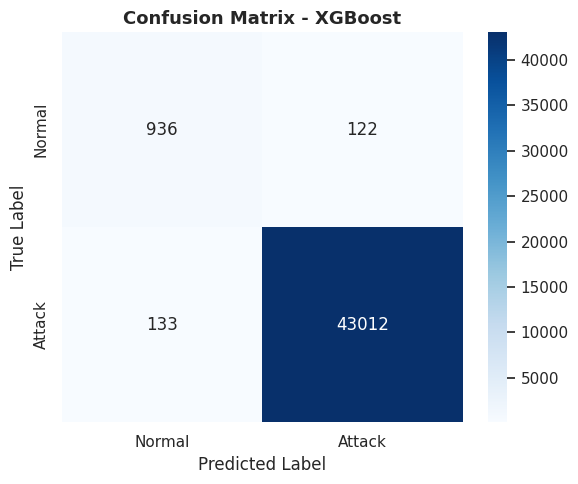


HYBRID AIS + PSO + ENSEMBLE VOTING
Accuracy          : 0.9945
Precision         : 0.9984
Recall            : 0.9960
F1-score          : 0.9972
Balanced Accuracy : 0.9663
False Positive Rate (FPR): 0.0633
True Negative Rate (TNR) : 0.9367

Confusion Matrix:
[[  991    67]
 [  174 42971]]


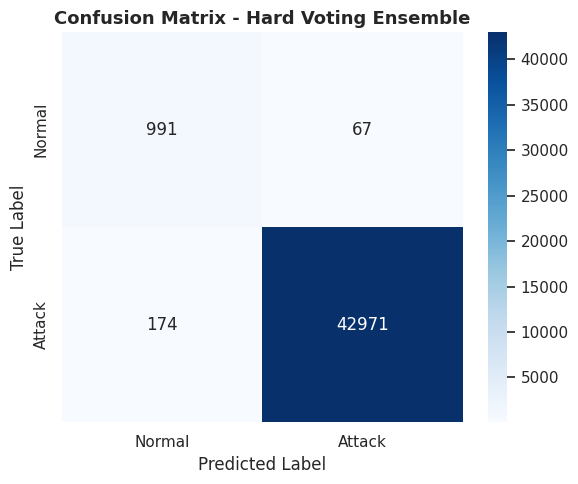


Best Soft Voting threshold: 0.54

HYBRID AIS + PSO + SOFT VOTING ENSEMBLE
Accuracy          : 0.9944
Precision         : 0.9983
Recall            : 0.9960
F1-score          : 0.9971
Balanced Accuracy : 0.9626
False Positive Rate (FPR): 0.0709
True Negative Rate (TNR) : 0.9291

Confusion Matrix:
[[  983    75]
 [  173 42972]]


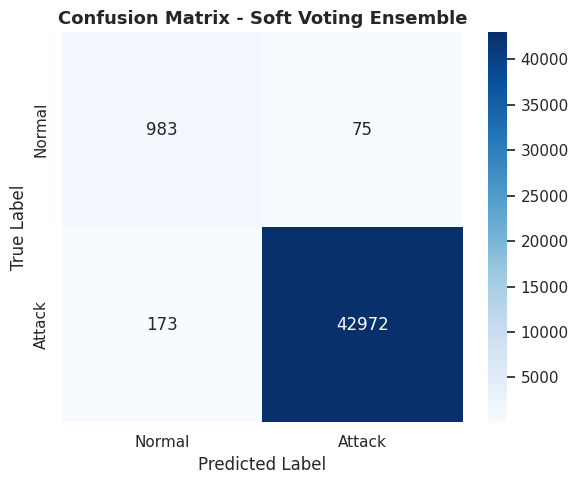

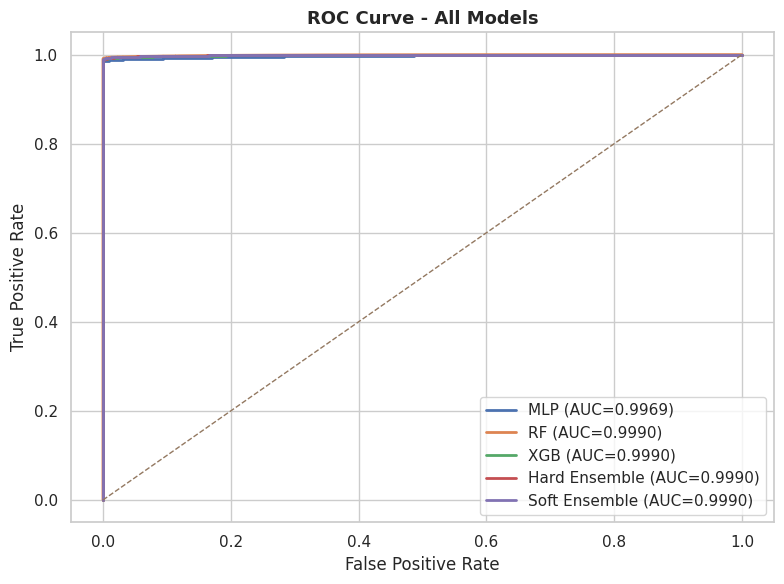

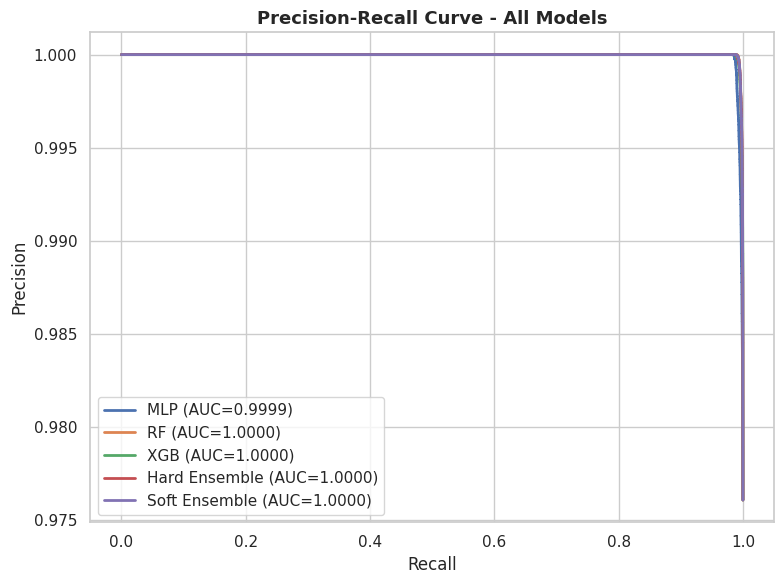

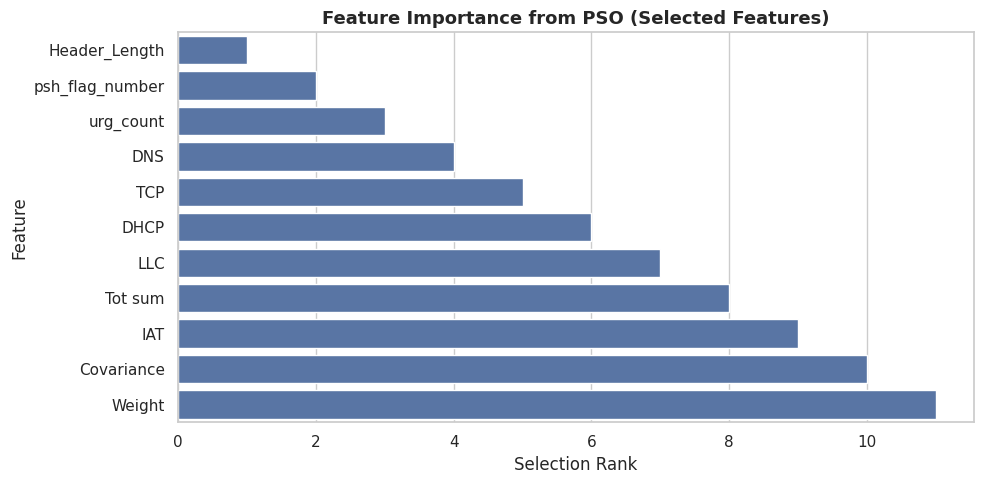

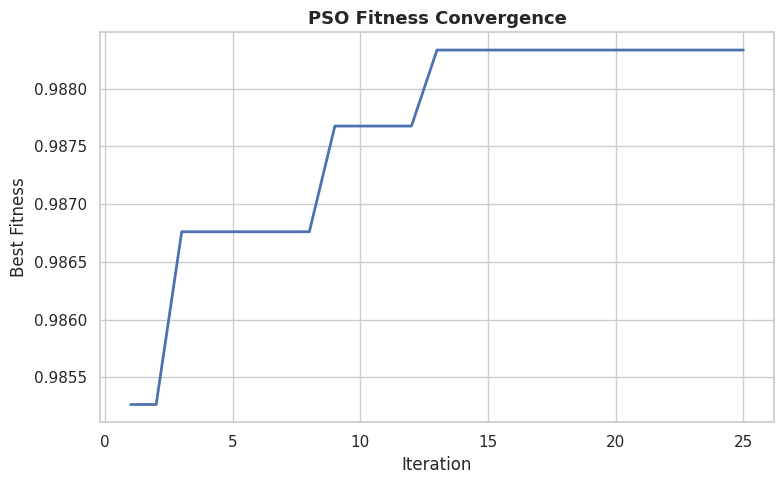


FINAL RESULTS SUMMARY
                  Model  Accuracy  Precision  Recall  F1-score  \
0                   MLP    0.9897     0.9962  0.9933    0.9947   
1         Random Forest    0.9946     0.9988  0.9956    0.9972   
2               XGBoost    0.9942     0.9972  0.9969    0.9970   
3  Hard Voting Ensemble    0.9945     0.9984  0.9960    0.9972   
4  Soft Voting Ensemble    0.9944     0.9983  0.9960    0.9971   

   Balanced Accuracy  False Positive Rate  True Negative Rate  ROC-AUC  PR-AUC  
0             0.9191               0.1550              0.8450   0.9969  0.9999  
1             0.9742               0.0473              0.9527   0.9990  1.0000  
2             0.9408               0.1153              0.8847   0.9990  1.0000  
3             0.9663               0.0633              0.9367   0.9990  1.0000  
4             0.9626               0.0709              0.9291   0.9990  1.0000  

Saved files:
/content/hybrid_ids_outputs/hybrid_selected_features.csv
/content/hybrid_ids_out

In [2]:
# =========================================================
# Step 4: Clean Labels and Optional Columns
# =========================================================
if 'difficulty' in train_df.columns:
    train_df = train_df.drop(columns=['difficulty'])
if 'difficulty' in test_df.columns:
    test_df = test_df.drop(columns=['difficulty'])

if 'label' not in train_df.columns:
    train_df.rename(columns={train_df.columns[-1]: 'label'}, inplace=True)
    test_df.rename(columns={test_df.columns[-1]: 'label'}, inplace=True)

train_df['label'] = train_df['label'].astype(str).str.strip()
test_df['label'] = test_df['label'].astype(str).str.strip()

# Detect normal/benign label automatically for CICIoT2023
train_unique_lower = set(train_df['label'].str.lower().unique().tolist())
test_unique_lower = set(test_df['label'].str.lower().unique().tolist())
all_unique_lower = train_unique_lower.union(test_unique_lower)

normal_keywords = ['normal', 'normal.', 'benign', 'benigntraffic']
normal_labels = [lbl for lbl in all_unique_lower if lbl in normal_keywords or 'benign' in lbl or 'normal' in lbl]

if len(normal_labels) == 0:
    # fallback: most frequent label in training set as normal
    fallback_normal = train_df['label'].str.lower().value_counts().idxmax()
    normal_labels = [fallback_normal]
    print(f"⚠️ No explicit benign/normal label found. Using most frequent label as normal: {fallback_normal}")

print("Detected normal labels:", normal_labels)

# Binary conversion: normal=0, attack=1
train_df['binary_label'] = train_df['label'].str.lower().apply(lambda x: 0 if x in normal_labels else 1)
test_df['binary_label'] = test_df['label'].str.lower().apply(lambda x: 0 if x in normal_labels else 1)

print("\nTrain binary distribution:")
print(train_df['binary_label'].value_counts())

print("\nTest binary distribution:")
print(test_df['binary_label'].value_counts())

# =========================================================
# Step 5: Encode Categorical Features
# =========================================================
combined_df = pd.concat(
    [train_df.drop(columns=['binary_label']), test_df.drop(columns=['binary_label'])],
    axis=0
).reset_index(drop=True)

# Encode all object/categorical columns except label
categorical_cols = combined_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'label']

print("\nCategorical columns:", categorical_cols)

for col in categorical_cols:
    le = LabelEncoder()
    combined_df[col] = le.fit_transform(combined_df[col].astype(str))

train_processed = combined_df.iloc[:len(train_df)].copy()
test_processed = combined_df.iloc[len(train_df):].copy()

# =========================================================
# Step 6: Separate Features and Labels
# =========================================================
X_train_full = train_processed.drop(columns=['label'])
X_test_full = test_processed.drop(columns=['label'])

y_train_full = train_df['binary_label'].values
y_test = test_df['binary_label'].values

X_train_full = X_train_full.select_dtypes(include=[np.number]).copy()
X_test_full = X_test_full.select_dtypes(include=[np.number]).copy()

# =========================================================
# Step 6.1: Remove Infinite and Missing Values
# =========================================================
X_train_full = X_train_full.replace([np.inf, -np.inf], np.nan)
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan)

train_mask = ~X_train_full.isna().any(axis=1)
test_mask = ~X_test_full.isna().any(axis=1)

X_train_full = X_train_full[train_mask]
y_train_full = y_train_full[train_mask]

X_test_full = X_test_full[test_mask]
y_test = y_test[test_mask]

# Remove constant columns
constant_cols = [col for col in X_train_full.columns if X_train_full[col].nunique() <= 1]
if len(constant_cols) > 0:
    X_train_full = X_train_full.drop(columns=constant_cols)
    X_test_full = X_test_full.drop(columns=constant_cols, errors='ignore')
    print("\nRemoved constant columns:", constant_cols)

# =========================================================
# Step 7: Standardization (Z-score)
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

X_train_full = pd.DataFrame(X_train_scaled, columns=X_train_full.columns)
X_test_full = pd.DataFrame(X_test_scaled, columns=X_test_full.columns)

# =========================================================
# Step 8: Train / Validation Split
# =========================================================
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test_full = X_test_full.reset_index(drop=True)

print("\nTrain:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test_full.shape)

# =========================================================
# Step 9: Balanced Subset for PSO
# =========================================================
def create_balanced_subset(X, y, samples_per_class=4000):
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]

    n_normal = min(len(normal_idx), samples_per_class)
    n_attack = min(len(attack_idx), samples_per_class)

    chosen_normal = np.random.choice(normal_idx, n_normal, replace=False)
    chosen_attack = np.random.choice(attack_idx, n_attack, replace=False)

    chosen_idx = np.concatenate([chosen_normal, chosen_attack])
    np.random.shuffle(chosen_idx)

    X_sub = X.iloc[chosen_idx].reset_index(drop=True)
    y_sub = y[chosen_idx]
    return X_sub, y_sub

X_pso, y_pso = create_balanced_subset(X_train, y_train, samples_per_class=4000)

# =========================================================
# Step 10: PSO Feature Selection using RF Fitness
# =========================================================
X_pso_np = X_pso.values
X_val_np = X_val.values

def fitness_function(particle, X_train_sub, X_val_full, y_train_sub, y_val, alpha=0.97):
    selected = np.where(particle == 1)[0]

    if len(selected) == 0:
        return 0.0

    Xtr = X_train_sub[:, selected]
    Xv = X_val_full[:, selected]

    clf = RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(Xtr, y_train_sub)
    preds = clf.predict(Xv)

    bal_acc = balanced_accuracy_score(y_val, preds)
    feature_ratio = len(selected) / X_train_sub.shape[1]
    fitness = alpha * bal_acc + (1 - alpha) * (1 - feature_ratio)
    return fitness

num_features = X_pso_np.shape[1]
num_particles = 20
num_iterations = 25
w, c1, c2 = 0.72, 1.49, 1.49

particles = np.random.randint(0, 2, size=(num_particles, num_features))
velocities = np.random.uniform(-1, 1, size=(num_particles, num_features))

for i in range(num_particles):
    if particles[i].sum() == 0:
        particles[i, np.random.randint(0, num_features)] = 1

pbest_positions = particles.copy()
pbest_scores = np.zeros(num_particles)
gbest_position = None
gbest_score = -1
gbest_history = []

for i in range(num_particles):
    score = fitness_function(particles[i], X_pso_np, X_val_np, y_pso, y_val)
    pbest_scores[i] = score
    if score > gbest_score:
        gbest_score = score
        gbest_position = particles[i].copy()

print("\nStarting PSO...")
for iteration in range(num_iterations):
    for i in range(num_particles):
        r1 = np.random.rand(num_features)
        r2 = np.random.rand(num_features)

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest_positions[i] - particles[i])
            + c2 * r2 * (gbest_position - particles[i])
        )

        sigmoid = 1 / (1 + np.exp(-velocities[i]))
        particles[i] = (np.random.rand(num_features) < sigmoid).astype(int)

        if particles[i].sum() == 0:
            particles[i, np.random.randint(0, num_features)] = 1

        score = fitness_function(particles[i], X_pso_np, X_val_np, y_pso, y_val)

        if score > pbest_scores[i]:
            pbest_scores[i] = score
            pbest_positions[i] = particles[i].copy()

        if score > gbest_score:
            gbest_score = score
            gbest_position = particles[i].copy()

    gbest_history.append(gbest_score)
    print(f"Iteration {iteration + 1}/{num_iterations}, Best Fitness: {gbest_score:.4f}")

selected_feature_indices = np.where(gbest_position == 1)[0]
selected_feature_names = X_train.columns[selected_feature_indices]

print("\nSelected feature count:", len(selected_feature_indices))
print("Selected features:", list(selected_feature_names))

X_train_sel = X_train.values[:, selected_feature_indices]
X_val_sel = X_val.values[:, selected_feature_indices]
X_test_sel = X_test_full.values[:, selected_feature_indices]

# =========================================================
# Step 11: Balanced AIS Training Data
# =========================================================
def create_balanced_numpy_subset(X, y, normal_count=5000, attack_count=5000):
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]

    n_normal = min(len(normal_idx), normal_count)
    n_attack = min(len(attack_idx), attack_count)

    chosen_normal = np.random.choice(normal_idx, n_normal, replace=False)
    chosen_attack = np.random.choice(attack_idx, n_attack, replace=False)

    return X[chosen_normal], X[chosen_attack]

self_samples, attack_samples = create_balanced_numpy_subset(
    X_train_sel, y_train, normal_count=5000, attack_count=5000
)

print("\nSelf samples :", self_samples.shape)
print("Attack samples:", attack_samples.shape)

# =========================================================
# Step 12: Negative Selection Detector Generation
# =========================================================
def generate_attack_detectors(self_samples, attack_samples, num_detectors=600, min_self_distance=0.6):
    detectors = []
    attempts = 0
    max_attempts = num_detectors * 100

    while len(detectors) < num_detectors and attempts < max_attempts:
        base = attack_samples[np.random.randint(0, len(attack_samples))].copy()
        candidate = base + np.random.normal(0, 0.08, size=base.shape)

        d_self = np.min(np.linalg.norm(self_samples - candidate, axis=1))

        if d_self >= min_self_distance:
            detectors.append(candidate)

        attempts += 1

    return np.array(detectors)

detectors = generate_attack_detectors(
    self_samples=self_samples,
    attack_samples=attack_samples,
    num_detectors=1000,
    min_self_distance=0.6
)

print("\nDetector shape:", detectors.shape)

# =========================================================
# Step 13: Create AIS Anomaly Features
# =========================================================
def create_ais_scores(X, detectors):
    feature_list = []

    for sample in X:
        dists = np.linalg.norm(detectors - sample, axis=1)
        sorted_dists = np.sort(dists)

        min_dist = np.min(dists)
        mean_dist = np.mean(dists)
        std_dist = np.std(dists)
        median_dist = np.median(dists)

        closest3_mean = np.mean(sorted_dists[:3]) if len(sorted_dists) >= 3 else np.mean(sorted_dists)
        closest5_mean = np.mean(sorted_dists[:5]) if len(sorted_dists) >= 5 else np.mean(sorted_dists)
        closest10_mean = np.mean(sorted_dists[:10]) if len(sorted_dists) >= 10 else np.mean(sorted_dists)

        activated_08 = np.sum(dists <= 0.8)
        activated_10 = np.sum(dists <= 1.0)
        activated_15 = np.sum(dists <= 1.5)

        affinities = 1 / (1 + dists)
        max_affinity = np.max(affinities)
        mean_affinity = np.mean(affinities)
        std_affinity = np.std(affinities)

        feature_list.append([
            min_dist,
            mean_dist,
            std_dist,
            median_dist,
            closest3_mean,
            closest5_mean,
            closest10_mean,
            activated_08,
            activated_10,
            activated_15,
            max_affinity,
            mean_affinity,
            std_affinity
        ])

    return np.array(feature_list)

X_train_ais = create_ais_scores(X_train_sel, detectors)
X_val_ais = create_ais_scores(X_val_sel, detectors)
X_test_ais = create_ais_scores(X_test_sel, detectors)

print("\nAIS feature shape (train):", X_train_ais.shape)

# =========================================================
# Step 14: Merge Selected Features + AIS Features
# =========================================================
X_train_hybrid = np.hstack((X_train_sel, X_train_ais))
X_val_hybrid = np.hstack((X_val_sel, X_val_ais))
X_test_hybrid = np.hstack((X_test_sel, X_test_ais))

print("Hybrid train shape:", X_train_hybrid.shape)
print("Hybrid val shape  :", X_val_hybrid.shape)
print("Hybrid test shape :", X_test_hybrid.shape)

# =========================================================
# Step 15: Evaluation + Visualization Helpers
# =========================================================
results_summary = []

def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0

    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    return {
        'cm': cm,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'balanced_accuracy': bal_acc,
        'fpr': fpr,
        'tnr': tnr,
        'roc_fpr': fpr_curve,
        'roc_tpr': tpr_curve,
        'roc_auc': roc_auc,
        'pr_precision': precision_curve,
        'pr_recall': recall_curve,
        'pr_auc': pr_auc
    }

def print_metrics(name, metrics_dict):
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print(f"Accuracy          : {metrics_dict['accuracy']:.4f}")
    print(f"Precision         : {metrics_dict['precision']:.4f}")
    print(f"Recall            : {metrics_dict['recall']:.4f}")
    print(f"F1-score          : {metrics_dict['f1']:.4f}")
    print(f"Balanced Accuracy : {metrics_dict['balanced_accuracy']:.4f}")
    print(f"False Positive Rate (FPR): {metrics_dict['fpr']:.4f}")
    print(f"True Negative Rate (TNR) : {metrics_dict['tnr']:.4f}")
    print("\nConfusion Matrix:")
    print(metrics_dict['cm'])

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

def add_results_row(name, metrics_dict):
    results_summary.append({
        'Model': name,
        'Accuracy': metrics_dict['accuracy'],
        'Precision': metrics_dict['precision'],
        'Recall': metrics_dict['recall'],
        'F1-score': metrics_dict['f1'],
        'Balanced Accuracy': metrics_dict['balanced_accuracy'],
        'False Positive Rate': metrics_dict['fpr'],
        'True Negative Rate': metrics_dict['tnr'],
        'ROC-AUC': metrics_dict['roc_auc'],
        'PR-AUC': metrics_dict['pr_auc']
    })

# =========================================================
# Step 16: Train MLP
# =========================================================
mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_hybrid.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nMLP MODEL SUMMARY")
mlp_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_hybrid, y_train,
    validation_data=(X_val_hybrid, y_val),
    epochs=80,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# Step 17: Training vs Validation Loss
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss (MLP)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 18: Threshold tuning for MLP
# =========================================================
mlp_val_probs = mlp_model.predict(X_val_hybrid).ravel()
candidate_thresholds = np.arange(0.30, 0.71, 0.02)

best_mlp_threshold = 0.50
best_mlp_f1 = -1

for th in candidate_thresholds:
    preds = (mlp_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_mlp_f1:
        best_mlp_f1 = score
        best_mlp_threshold = th

print(f"\nBest MLP threshold: {best_mlp_threshold:.2f}")

mlp_test_probs = mlp_model.predict(X_test_hybrid).ravel()
mlp_pred = (mlp_test_probs >= best_mlp_threshold).astype(int)

mlp_metrics = compute_metrics(y_test, mlp_pred, mlp_test_probs)
print_metrics("HYBRID AIS + PSO + MLP", mlp_metrics)
plot_confusion_matrix(mlp_metrics['cm'], "Confusion Matrix - MLP")
add_results_row("MLP", mlp_metrics)

# =========================================================
# Step 19: Train Random Forest
# =========================================================
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_hybrid, y_train)

rf_val_probs = rf_model.predict_proba(X_val_hybrid)[:, 1]
best_rf_threshold = 0.50
best_rf_f1 = -1

for th in candidate_thresholds:
    preds = (rf_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_rf_f1:
        best_rf_f1 = score
        best_rf_threshold = th

print(f"Best RF threshold : {best_rf_threshold:.2f}")

rf_test_probs = rf_model.predict_proba(X_test_hybrid)[:, 1]
rf_pred = (rf_test_probs >= best_rf_threshold).astype(int)

rf_metrics = compute_metrics(y_test, rf_pred, rf_test_probs)
print_metrics("HYBRID AIS + PSO + RANDOM FOREST", rf_metrics)
plot_confusion_matrix(rf_metrics['cm'], "Confusion Matrix - Random Forest")
add_results_row("Random Forest", rf_metrics)

# =========================================================
# Step 20: Train XGBoost
# =========================================================
xgb_model = XGBClassifier(
    n_estimators=900,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.90,
    colsample_bytree=0.90,
    gamma=0.1,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_hybrid, y_train,
    eval_set=[(X_val_hybrid, y_val)],
    verbose=False
)

xgb_val_probs = xgb_model.predict_proba(X_val_hybrid)[:, 1]
best_xgb_threshold = 0.50
best_xgb_f1 = -1

for th in candidate_thresholds:
    preds = (xgb_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_xgb_f1:
        best_xgb_f1 = score
        best_xgb_threshold = th

print(f"Best XGB threshold: {best_xgb_threshold:.2f}")

xgb_test_probs = xgb_model.predict_proba(X_test_hybrid)[:, 1]
xgb_pred = (xgb_test_probs >= best_xgb_threshold).astype(int)

xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_test_probs)
print_metrics("HYBRID AIS + PSO + XGBOOST", xgb_metrics)
plot_confusion_matrix(xgb_metrics['cm'], "Confusion Matrix - XGBoost")
add_results_row("XGBoost", xgb_metrics)

# =========================================================
# Step 21: Ensemble Voting (Hard)
# =========================================================
ensemble_votes = mlp_pred + rf_pred + xgb_pred
ensemble_pred = (ensemble_votes >= 2).astype(int)

hard_vote_probs = (mlp_test_probs + rf_test_probs + xgb_test_probs) / 3.0

ensemble_metrics = compute_metrics(y_test, ensemble_pred, hard_vote_probs)
print_metrics("HYBRID AIS + PSO + ENSEMBLE VOTING", ensemble_metrics)
plot_confusion_matrix(ensemble_metrics['cm'], "Confusion Matrix - Hard Voting Ensemble")
add_results_row("Hard Voting Ensemble", ensemble_metrics)

# =========================================================
# Step 22: Soft Voting
# =========================================================
soft_probs = (
    0.15 * mlp_test_probs +
    0.30 * rf_test_probs +
    0.55 * xgb_test_probs
)

best_soft_threshold = 0.50
best_soft_f1 = -1

soft_val_probs = (
    0.15 * mlp_val_probs +
    0.30 * rf_val_probs +
    0.55 * xgb_val_probs
)

for th in candidate_thresholds:
    preds = (soft_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_soft_f1:
        best_soft_f1 = score
        best_soft_threshold = th

print(f"\nBest Soft Voting threshold: {best_soft_threshold:.2f}")

soft_ensemble_pred = (soft_probs >= best_soft_threshold).astype(int)

soft_metrics = compute_metrics(y_test, soft_ensemble_pred, soft_probs)
print_metrics("HYBRID AIS + PSO + SOFT VOTING ENSEMBLE", soft_metrics)
plot_confusion_matrix(soft_metrics['cm'], "Confusion Matrix - Soft Voting Ensemble")
add_results_row("Soft Voting Ensemble", soft_metrics)

# =========================================================
# Step 23: ROC Curve (All Models)
# =========================================================
plt.figure(figsize=(8, 6))
plt.plot(mlp_metrics['roc_fpr'], mlp_metrics['roc_tpr'], label=f"MLP (AUC={mlp_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(rf_metrics['roc_fpr'], rf_metrics['roc_tpr'], label=f"RF (AUC={rf_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(xgb_metrics['roc_fpr'], xgb_metrics['roc_tpr'], label=f"XGB (AUC={xgb_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(ensemble_metrics['roc_fpr'], ensemble_metrics['roc_tpr'], label=f"Hard Ensemble (AUC={ensemble_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(soft_metrics['roc_fpr'], soft_metrics['roc_tpr'], label=f"Soft Ensemble (AUC={soft_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("ROC Curve - All Models", fontsize=13, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 24: Precision-Recall Curve (All Models)
# =========================================================
plt.figure(figsize=(8, 6))
plt.plot(mlp_metrics['pr_recall'], mlp_metrics['pr_precision'], label=f"MLP (AUC={mlp_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(rf_metrics['pr_recall'], rf_metrics['pr_precision'], label=f"RF (AUC={rf_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(xgb_metrics['pr_recall'], xgb_metrics['pr_precision'], label=f"XGB (AUC={xgb_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(ensemble_metrics['pr_recall'], ensemble_metrics['pr_precision'], label=f"Hard Ensemble (AUC={ensemble_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(soft_metrics['pr_recall'], soft_metrics['pr_precision'], label=f"Soft Ensemble (AUC={soft_metrics['pr_auc']:.4f})", linewidth=2)
plt.title("Precision-Recall Curve - All Models", fontsize=13, fontweight='bold')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 25: Feature Importance from PSO
# =========================================================
selected_mask = np.zeros(num_features)
selected_mask[selected_feature_indices] = 1

pso_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected_by_PSO': selected_mask.astype(int)
}).sort_values(by='Selected_by_PSO', ascending=False)

top_selected_features = pd.DataFrame({
    'Feature': selected_feature_names,
    'Selection_Order': np.arange(1, len(selected_feature_names) + 1)
})

plt.figure(figsize=(10, max(5, len(selected_feature_names) * 0.25)))
sns.barplot(
    data=top_selected_features,
    y='Feature',
    x='Selection_Order',
    orient='h'
)
plt.title("Feature Importance from PSO (Selected Features)", fontsize=13, fontweight='bold')
plt.xlabel("Selection Rank")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# =========================================================
# Step 26: PSO Fitness Convergence Curve
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gbest_history) + 1), gbest_history, linewidth=2)
plt.title("PSO Fitness Convergence", fontsize=13, fontweight='bold')
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.tight_layout()
plt.show()

# =========================================================
# Step 27: Results Summary Table
# =========================================================
results_df = pd.DataFrame(results_summary)
print("\nFINAL RESULTS SUMMARY")
print(results_df.round(4))

# =========================================================
# Step 28: Save Results
# =========================================================
output_dir = '/content/hybrid_ids_outputs'
os.makedirs(output_dir, exist_ok=True)

selected_features_df = pd.DataFrame({
    "Selected_Features": selected_feature_names
})
selected_features_df.to_csv(f'{output_dir}/hybrid_selected_features.csv', index=False)

ais_feature_names = [
    'min_dist', 'mean_dist', 'std_dist', 'median_dist',
    'closest3_mean', 'closest5_mean', 'closest10_mean',
    'activated_08', 'activated_10', 'activated_15',
    'max_affinity', 'mean_affinity', 'std_affinity'
]

train_ais_df = pd.DataFrame(X_train_ais, columns=ais_feature_names)
train_ais_df.to_csv(f'{output_dir}/train_ais_scores.csv', index=False)

pred_df = pd.DataFrame({
    'Actual': y_test,
    'MLP_Prob': mlp_test_probs,
    'MLP_Pred': mlp_pred,
    'RF_Prob': rf_test_probs,
    'RF_Pred': rf_pred,
    'XGB_Prob': xgb_test_probs,
    'XGB_Pred': xgb_pred,
    'Hard_Ensemble_Pred': ensemble_pred,
    'Soft_Prob': soft_probs,
    'Soft_Ensemble_Pred': soft_ensemble_pred
})
pred_df.to_csv(f'{output_dir}/hybrid_ensemble_predictions.csv', index=False)

results_df.to_csv(f'{output_dir}/model_results_summary.csv', index=False)
pso_importance_df.to_csv(f'{output_dir}/pso_feature_importance.csv', index=False)

print("\nSaved files:")
print(f"{output_dir}/hybrid_selected_features.csv")
print(f"{output_dir}/train_ais_scores.csv")
print(f"{output_dir}/hybrid_ensemble_predictions.csv")
print(f"{output_dir}/model_results_summary.csv")
print(f"{output_dir}/pso_feature_importance.csv")